In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import cmocean.cm as cmo

from pathlib import Path

import src.analysis.plots as plots
import src.statistics.corrfiles as cf

ROOT = cf.get_base_dir()

DESI_ROOT_DR2 = Path(
    "/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP"
)
PAPER_FIGURES_ROOT = Path(f"{ROOT}/paper/figures/")
if not PAPER_FIGURES_ROOT.exists():
    PAPER_FIGURES_ROOT.mkdir(parents=True)
moc_list = sorted(
    [
        Path(
            f"{ROOT}/data/mocs/",
            f"hsc_moc{i+1}.fits",
        )
        for i in range(0, 4)
    ]
)
cmap_hsc = plt.get_cmap("plasma")
cmap_desi = plt.get_cmap("viridis")

# plot infrastructure
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

In [4]:
version = "vF"
scale_cut = [1, 5]
expects1 = np.load(
    f"{ROOT}/results/expectations_{scale_cut[0]}_{scale_cut[1]}_{version}.npz"
)
scale_cut = [0.3, 3]
expects2 = np.load(
    f"{ROOT}/results/expectations_{scale_cut[0]}_{scale_cut[1]}_{version}.npz"
)

centers = [0.452, 0.766, 1.081, 1.330]
centers_err = [0.024, 0.022, 0.031, 0.034]

In [5]:
names = ["npz_cross", "npz_bs", "npz_bs_bp", "npz_bs_bp_mag"]  #'npz_cross',
name_to_label = {
    "npz_cross": "No bias evolution",
    "npz_bs": r"$b_s(z)$",
    "npz_bs_bp": r"$b_s(z), b_p(z)$",
    "npz_bs_bp_mag": r"$b_s(z), b_p(z), \mu$",
}

In [6]:
data = {
    "Y3 Power Spectrum (Dalal+2023)": [
        None,
        None,
        (-0.075, (0.059, 0.056)),
        (-0.157, (0.111, 0.094)),
    ],
    "Y3 Real Space (Li+2023)": [
        None,
        None,
        (-0.115, (0.058, 0.052)),
        (-0.192, (0.088, 0.088)),
    ],
    "Y3 CSR (Rana+2025)": [
        None,
        (+0.002, (0.022, 0.021)),
        (-0.002, (0.217, 0.085)),
        (-0.292, (0.324, 0.229)),
    ],
    "Y3 GC-WL (Zhang+2025)": [
        None,
        None,
        (-0.112, (0.046, 0.049)),
        (-0.185, (0.071, 0.081)),
    ],
    "Y3 PhotZ (Rau+2022)": [
        (-0.011, (0.005, 0.005)),
        (0, (0.004, 0.004)),
        (-0.003, (0.004, 0.004)),
        (0, (0.003, 0.003)),
    ],
    "Y3 PhotZ & WX (Rau+2022)": [
        (0, (0.004, 0.004)),
        (0, (0.003, 0.003)),
        (0, (0.004, 0.004)),
        None,
    ],
    "Y3 Total (Rau+2022)": [
        (0, (0.024, 0.024)),
        (0, (0.022, 0.022)),
        (0, (0.031, 0.031)),
        (0, (0.034, 0.034)),
    ],
}


def format_expect(tomo, name, expects):
    p16, p50, p84 = expects[f"{tomo}/{name}"]
    center = centers[tomo - 1]

    shift = center - p50
    err_low = p50 - p16
    err_high = p84 - p50

    return (shift, (err_low, err_high))


data.update(
    {
        f"1{name_to_label[name]}": [
            format_expect(tomo, name, expects1) for tomo in range(1, 5)
        ]
        for name in names
    }
)
data.update(
    {
        f"2{name_to_label[name]}": [
            format_expect(tomo, name, expects2) for tomo in range(1, 5)
        ]
        for name in names
    }
)
print(data)

{'Y3 Power Spectrum (Dalal+2023)': [None, None, (-0.075, (0.059, 0.056)), (-0.157, (0.111, 0.094))], 'Y3 Real Space (Li+2023)': [None, None, (-0.115, (0.058, 0.052)), (-0.192, (0.088, 0.088))], 'Y3 CSR (Rana+2025)': [None, (0.002, (0.022, 0.021)), (-0.002, (0.217, 0.085)), (-0.292, (0.324, 0.229))], 'Y3 GC-WL (Zhang+2025)': [None, None, (-0.112, (0.046, 0.049)), (-0.185, (0.071, 0.081))], 'Y3 PhotZ (Rau+2022)': [(-0.011, (0.005, 0.005)), (0, (0.004, 0.004)), (-0.003, (0.004, 0.004)), (0, (0.003, 0.003))], 'Y3 PhotZ & WX (Rau+2022)': [(0, (0.004, 0.004)), (0, (0.003, 0.003)), (0, (0.004, 0.004)), None], 'Y3 Total (Rau+2022)': [(0, (0.024, 0.024)), (0, (0.022, 0.022)), (0, (0.031, 0.031)), (0, (0.034, 0.034))], '1No bias evolution': [(np.float64(-0.009954395810559735), (np.float64(0.011276702730834753), np.float64(0.010383997620389773))), (np.float64(-0.03241004626901378), (np.float64(0.012826278976129868), np.float64(0.014182657292361789))), (np.float64(-0.09381963484345768), (np.float6

$\Delta z_1$, Y3 PhotZ (Rau+2022): -0.011^{+0.005}_{-0.005}
$\Delta z_1$, Y3 PhotZ & WX (Rau+2022): 0.000^{+0.004}_{-0.004}
$\Delta z_1$, Y3 Total (Rau+2022): 0.000^{+0.024}_{-0.024}
$\Delta z_1$, 1No bias evolution: -0.010^{+0.010}_{-0.011}
$\Delta z_1$, 1$b_s(z)$: 0.014^{+0.012}_{-0.012}
$\Delta z_1$, 1$b_s(z), b_p(z)$: 0.026^{+0.013}_{-0.013}
$\Delta z_1$, 1$b_s(z), b_p(z), \mu$: 0.028^{+0.013}_{-0.014}
$\Delta z_1$, 2No bias evolution: -0.009^{+0.006}_{-0.006}
$\Delta z_1$, 2$b_s(z)$: 0.013^{+0.007}_{-0.007}
$\Delta z_1$, 2$b_s(z), b_p(z)$: 0.025^{+0.008}_{-0.008}
$\Delta z_1$, 2$b_s(z), b_p(z), \mu$: 0.029^{+0.008}_{-0.008}
$\Delta z_2$, Y3 CSR (Rana+2025): 0.002^{+0.021}_{-0.022}
$\Delta z_2$, Y3 PhotZ (Rau+2022): 0.000^{+0.004}_{-0.004}
$\Delta z_2$, Y3 PhotZ & WX (Rau+2022): 0.000^{+0.003}_{-0.003}
$\Delta z_2$, Y3 Total (Rau+2022): 0.000^{+0.022}_{-0.022}
$\Delta z_2$, 1No bias evolution: -0.032^{+0.014}_{-0.013}
$\Delta z_2$, 1$b_s(z)$: -0.033^{+0.015}_{-0.014}
$\Delta z_2$, 

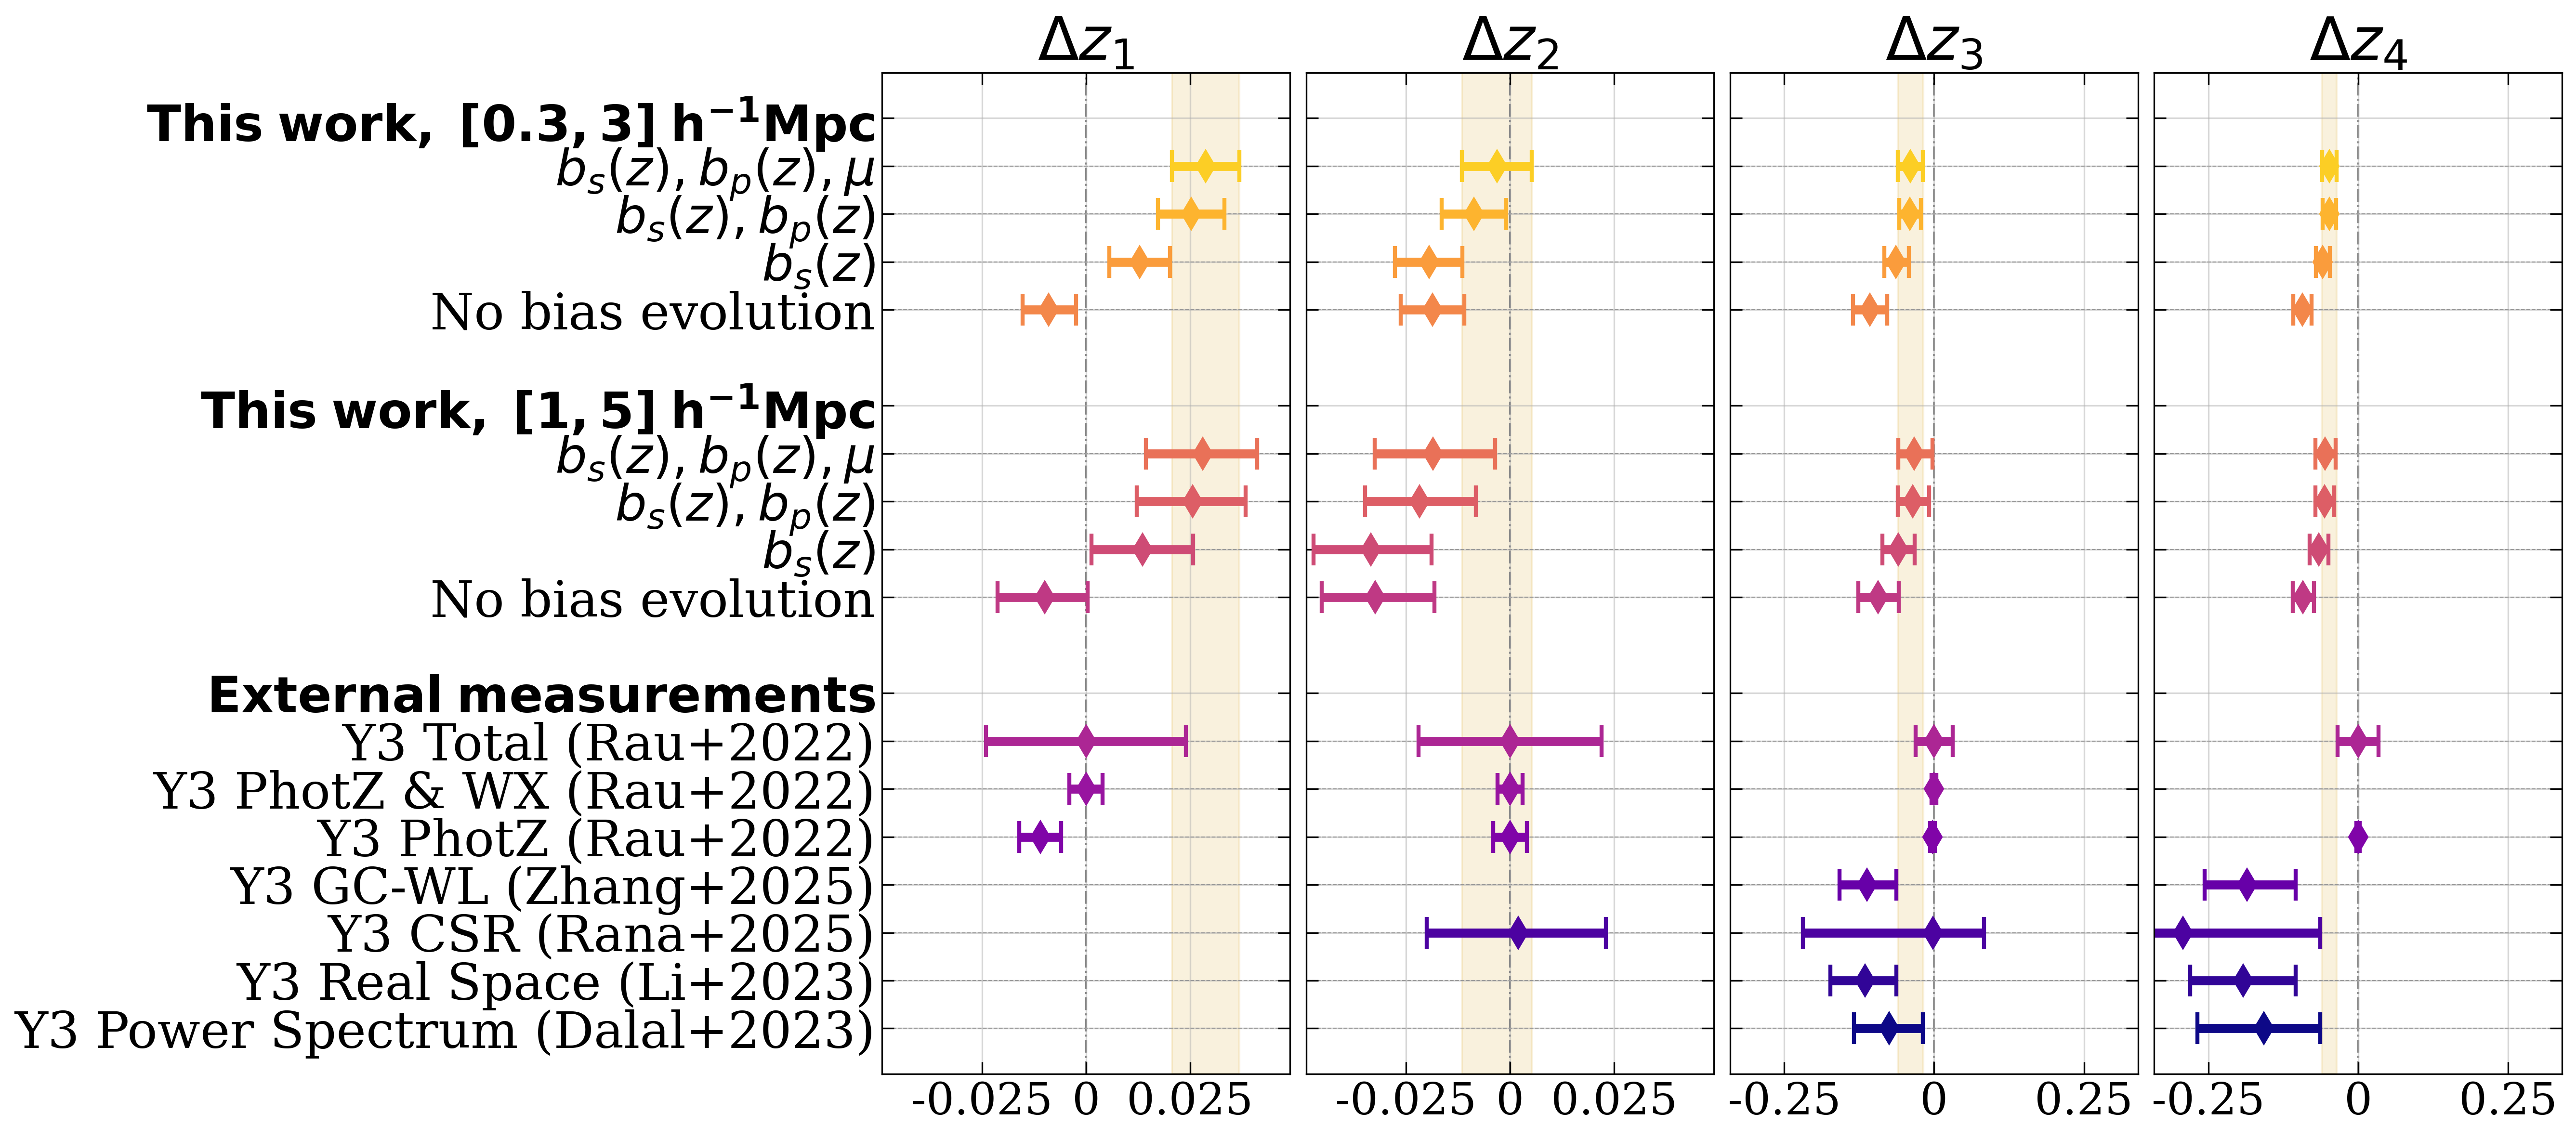

In [7]:
shifts_dz = [r"$\Delta z_1$", r"$\Delta z_2$", r"$\Delta z_3$", r"$\Delta z_4$"]
n_shifts_dz = len(shifts_dz)

block_orig = [k for k in data.keys() if not (k.startswith("1") or k.startswith("2"))]
block1 = [k for k in data.keys() if k.startswith("1")]
block2 = [k for k in data.keys() if k.startswith("2")]

spacing = 1

labels = (
    block_orig
    + ["External\; measurements Section"]
    + [""] * spacing
    + block1
    + ["This\; work,\;" + r"[1, 5]\; h^{-1}Mpc" + "Section"]
    + [""] * spacing
    + block2
    + ["This\; work,\;" + r"[0.3, 3]\; h^{-1}Mpc" + "Section"]
)

n_labels = len(labels)
y_pos = np.linspace(0, 1, n_labels)

real_labels = block_orig + block1 + block2
colors = plt.get_cmap("plasma")(np.linspace(0, 0.9, len(real_labels)))

with pm.make_plot(
    "shifts",
    nrows=1,
    ncols=n_shifts_dz,
    figsize=(15, 9),
    show=True,
    sharey=True,
    tight_layout=False,
) as (fig, axs):

    fig.subplots_adjust(wspace=0.04)

    for i, (ax, const_name) in enumerate(zip(axs, shifts_dz)):
        for j, label in enumerate(labels):
            if label == "" or "Section" in label:
                continue

            entry = data[label][i]
            if entry is not None:
                col = colors[real_labels.index(label)]
                val, (err_low, err_high) = entry
                ax.errorbar(
                    val,
                    y_pos[j],
                    xerr=[[err_low], [err_high]],
                    fmt="d",
                    color=col,
                    capthick=2,
                    capsize=8,
                    linewidth=4.5,
                    markersize=11,
                )
                print(
                    f"{const_name}, {label}: {val:.3f}^{{+{err_high:.3f}}}_{{-{err_low:.3f}}}"
                )

        ax.set_title(const_name, fontsize=30)
        ax.set_ylim(-0.05, 1.05)

        for label, y in zip(labels, y_pos):
            if label != "" and "Section" not in label:
                ax.axhline(y, color="gray", linestyle="--", linewidth=0.5, zorder=0)

        ax.axvline(0, color="gray", linestyle="-.", linewidth=1, zorder=0)

        values_with_errors = [
            (val, err_low, err_high)
            for label in labels
            if label != ""
            and "Section" not in label
            and (entry := data[label][i]) is not None
            for val, (err_low, err_high) in [entry]
        ]

        if i == 0 or i == 1:
            ax.set_xlim(-0.049, 0.049)
        if i == 2 or i == 3:
            ax.set_xlim(-0.34, 0.34)

        last_val = None
        last_err_low = None
        last_err_high = None

        for label in reversed(labels):
            if label == "" or "Section" in label:
                continue
            entry = data[label][i]
            if entry is not None:
                last_val, (last_err_low, last_err_high) = entry
                break

        if last_val is not None:
            band_start = last_val - max(last_err_low, last_err_high)
            band_end = last_val + max(last_err_low, last_err_high)
            ax.axvspan(band_start, band_end, color="goldenrod", alpha=0.15, zorder=-1)

        from matplotlib.ticker import FuncFormatter

        def xfmt(x, pos):
            s = f"{x:.3f}".rstrip("0").rstrip(".")
            return s

        ax.xaxis.set_major_formatter(FuncFormatter(xfmt))
        ax.tick_params(axis="x", labelsize=22)

    ytick_positions = [y for label, y in zip(labels, y_pos) if label != ""]
    ytick_labels = []
    for label in labels:
        if label == "":
            continue
        if "Section" in label:
            # remove "Section"
            label = label.replace("Section", "").strip()
            # section header in bold
            ytick_labels.append(r"$\bf{" + label + "}$")
        else:
            # remove leading "1" or "2" from labels
            if label[0] in ("1", "2"):
                ytick_labels.append(label[1:].strip())
            else:
                ytick_labels.append(label)

    axs[0].set_yticks(ytick_positions)
    axs[0].set_yticklabels(ytick_labels, fontsize=25)

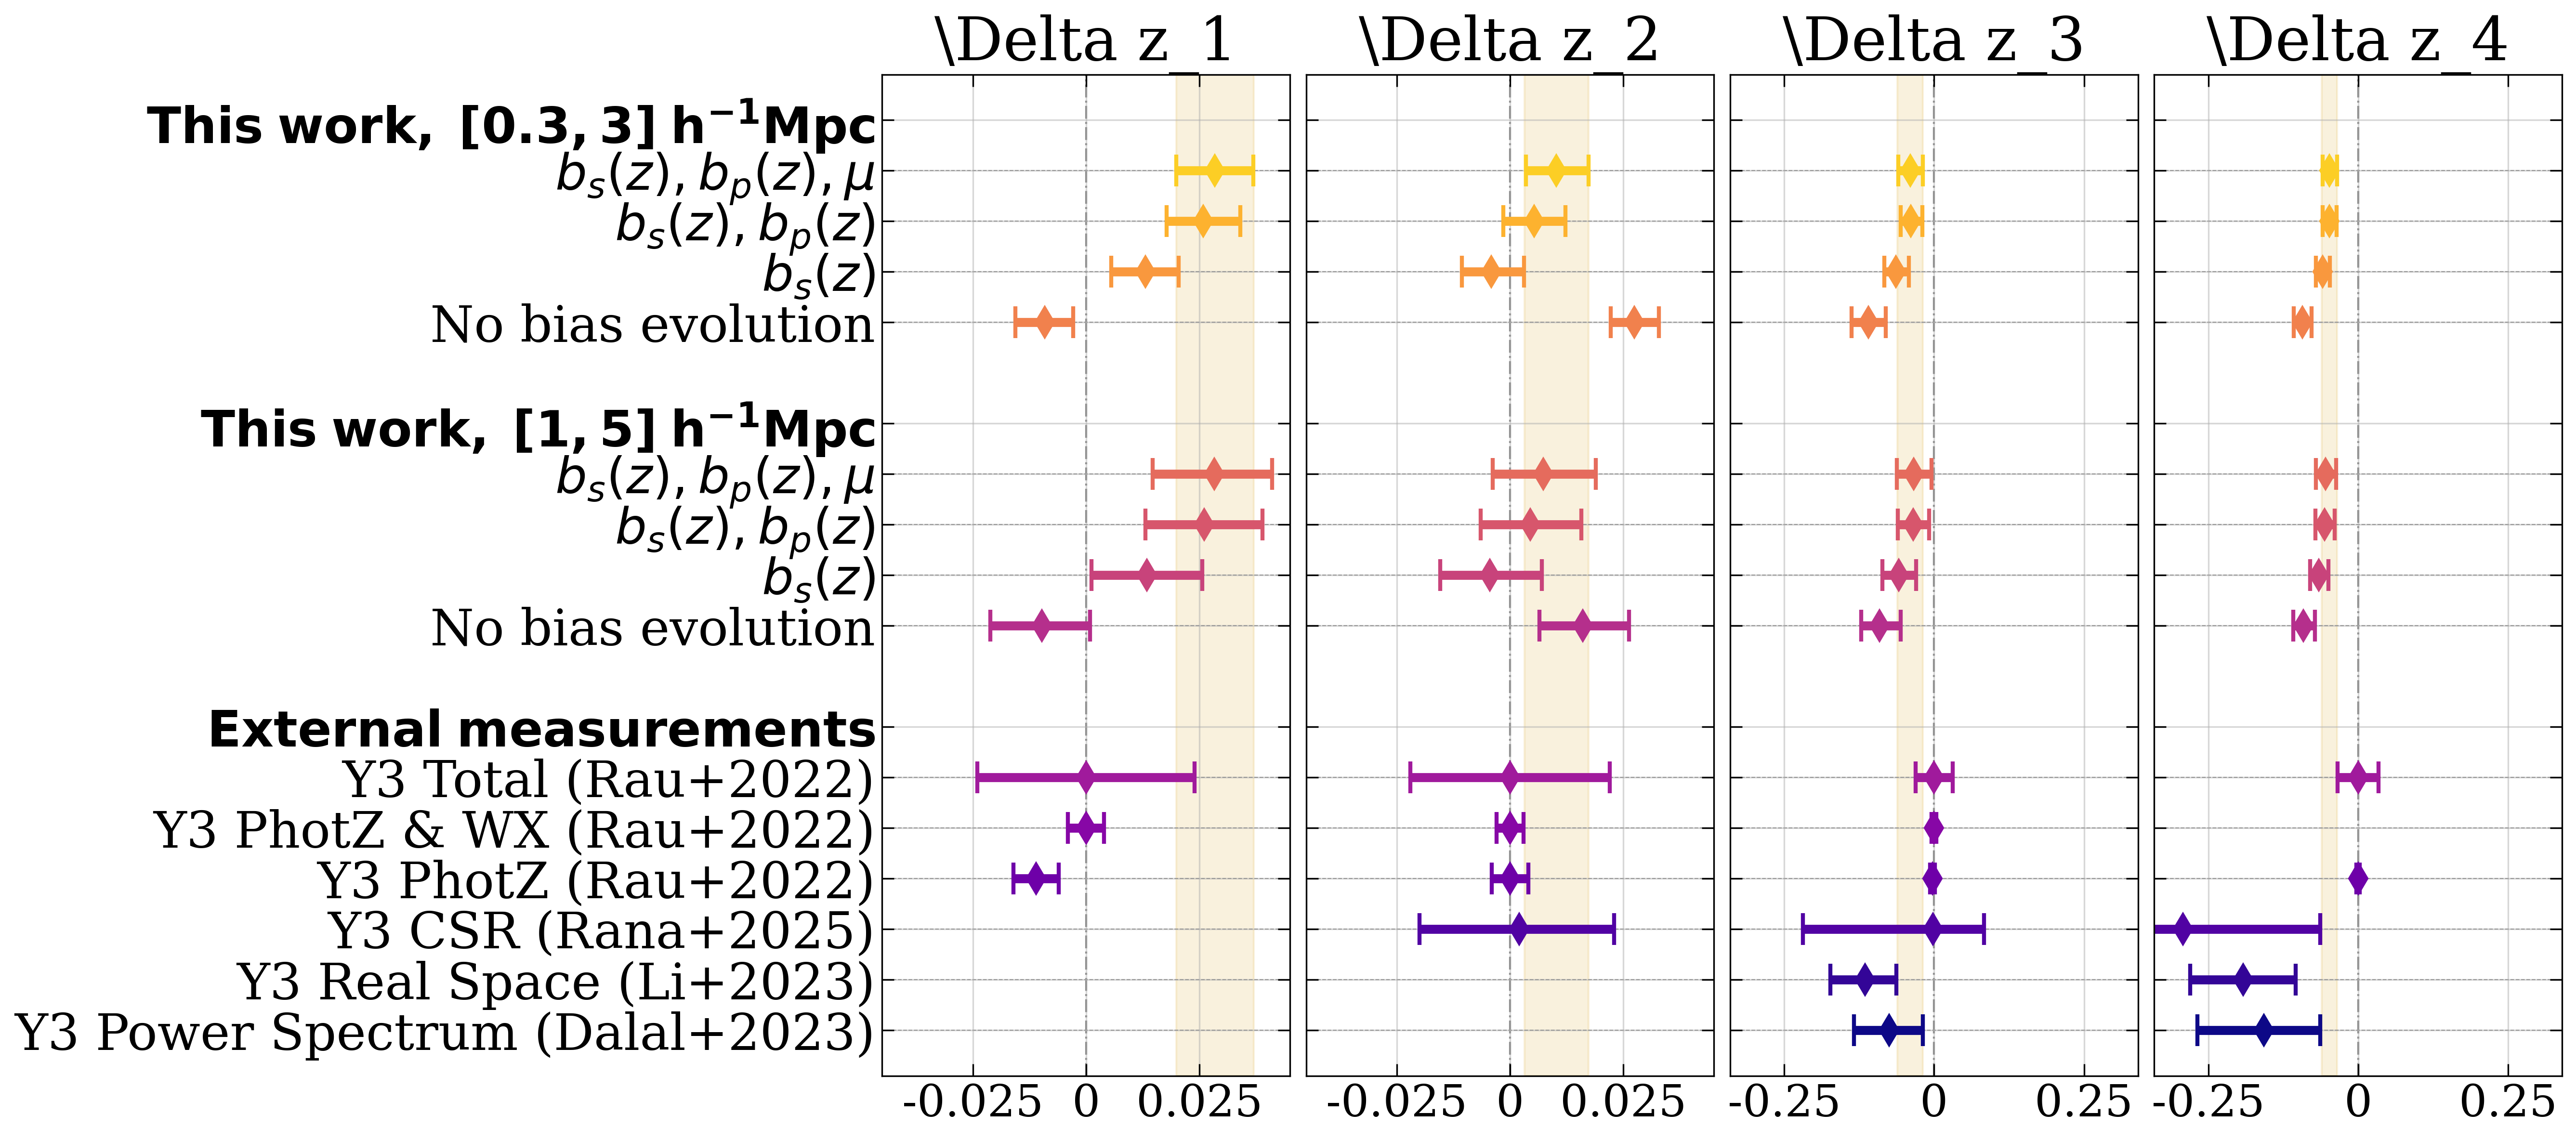

$\Delta z_1$, Y3 PhotZ (Rau+2022): -0.0110^{+0.0050}_{-0.0050}
$\Delta z_1$, Y3 PhotZ & WX (Rau+2022): 0.0000^{+0.0040}_{-0.0040}
$\Delta z_1$, Y3 Total (Rau+2022): 0.0000^{+0.0240}_{-0.0240}
$\Delta z_1$, 1No bias evolution: -0.0098^{+0.0107}_{-0.0114}
$\Delta z_1$, 1$b_s(z)$: 0.0134^{+0.0123}_{-0.0122}
$\Delta z_1$, 1$b_s(z), b_p(z)$: 0.0261^{+0.0128}_{-0.0130}
$\Delta z_1$, 1$b_s(z), b_p(z), \mu$: 0.0283^{+0.0128}_{-0.0136}
$\Delta z_1$, 2No bias evolution: -0.0058^{+0.0072}_{-0.0075}
$\Delta z_1$, 2$b_s(z)$: 0.0162^{+0.0078}_{-0.0083}
$\Delta z_1$, 2$b_s(z), b_p(z)$: 0.0294^{+0.0087}_{-0.0090}
$\Delta z_1$, 2$b_s(z), b_p(z), \mu$: 0.0338^{+0.0094}_{-0.0093}
$\Delta z_2$, Y3 CSR (Rana+2025): 0.0020^{+0.0210}_{-0.0220}
$\Delta z_2$, Y3 PhotZ (Rau+2022): 0.0000^{+0.0040}_{-0.0040}
$\Delta z_2$, Y3 PhotZ & WX (Rau+2022): 0.0000^{+0.0030}_{-0.0030}
$\Delta z_2$, Y3 Total (Rau+2022): 0.0000^{+0.0220}_{-0.0220}
$\Delta z_2$, 1No bias evolution: 0.0160^{+0.0102}_{-0.0096}
$\Delta z_2$, 1$b

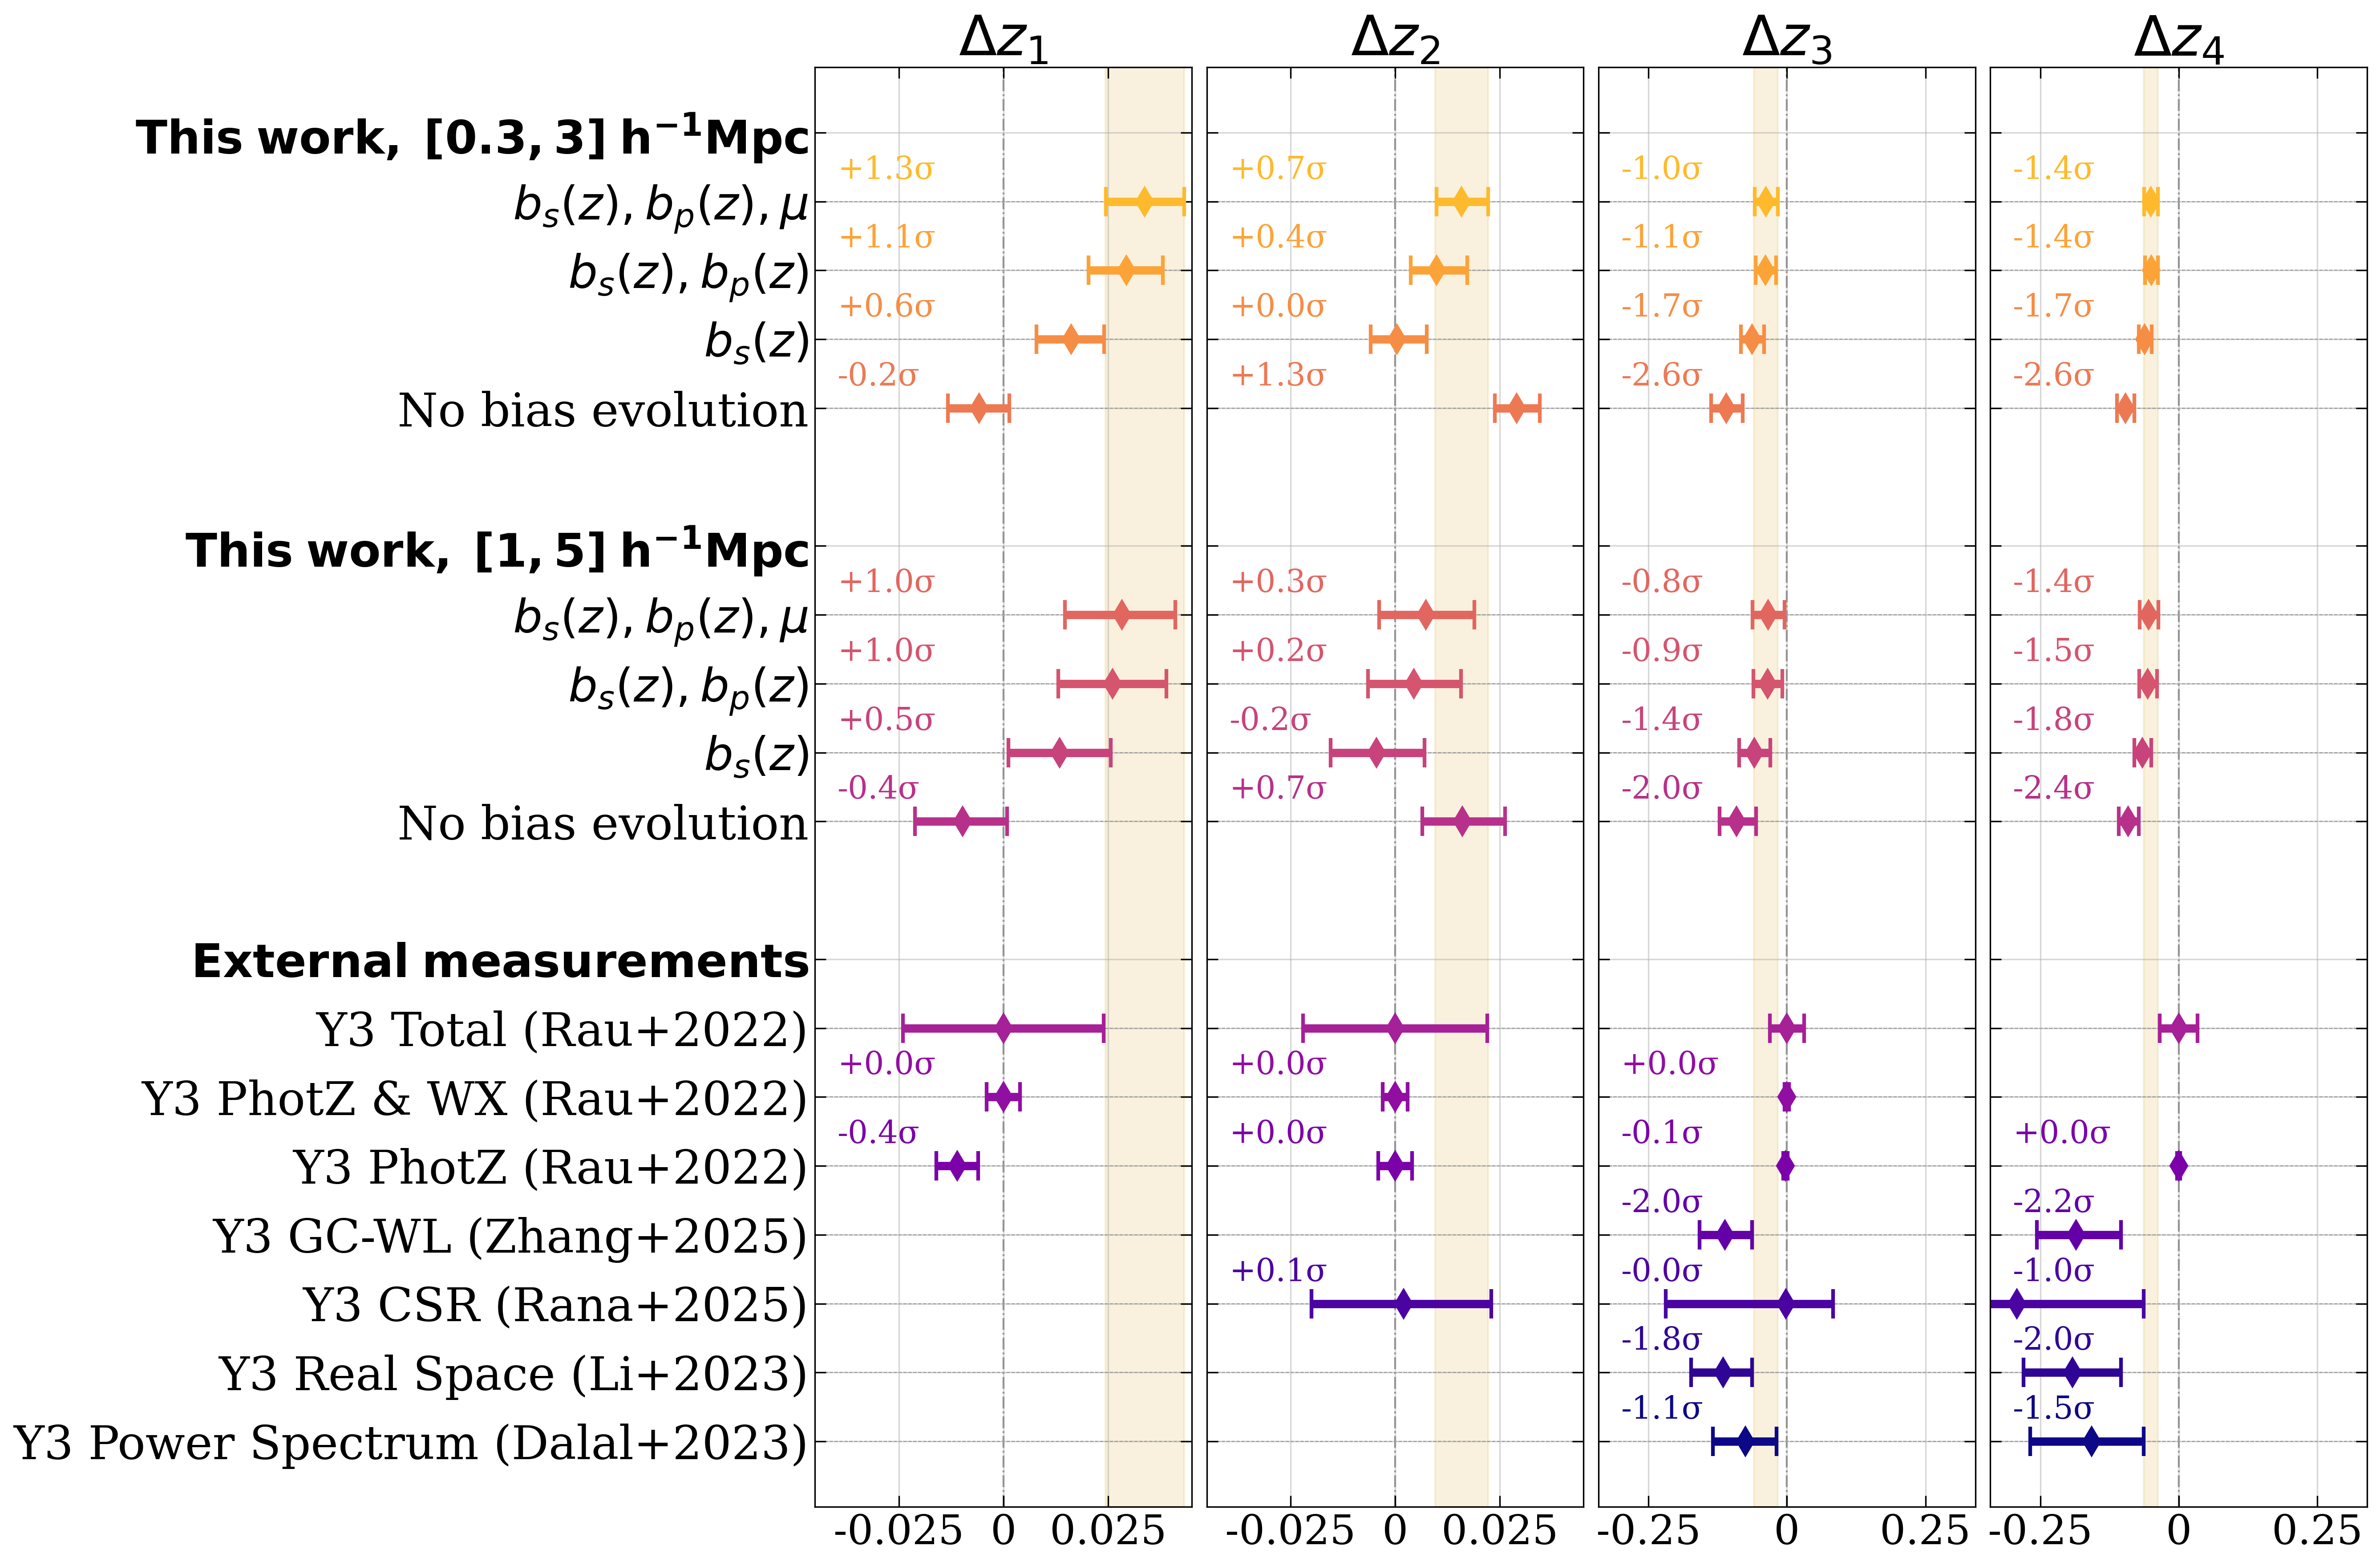

In [7]:
shifts_dz = [r"$\Delta z_1$", r"$\Delta z_2$", r"$\Delta z_3$", r"$\Delta z_4$"]
n_shifts_dz = len(shifts_dz)

block_orig = [k for k in data.keys() if not (k.startswith("1") or k.startswith("2"))]
block1 = [k for k in data.keys() if k.startswith("1")]
block2 = [k for k in data.keys() if k.startswith("2")]

spacing = 1

labels = (
    block_orig
    + ["External\; measurements Section"]
    + [""] * spacing
    + block1
    + ["This\; work,\;" + r"[1, 5]\; h^{-1}Mpc" + "Section"]
    + [""] * spacing
    + block2
    + ["This\; work,\;" + r"[0.3, 3]\; h^{-1}Mpc" + "Section"]
)

n_labels = len(labels)
y_pos = np.linspace(0, 1, n_labels)
y3_label = "Y3 Total (Rau+2022)"

real_labels = block_orig + block1 + block2
colors = plt.get_cmap("plasma")(np.linspace(0, 0.85, len(real_labels)))

with pm.make_plot(
    "shifts",
    nrows=1,
    ncols=n_shifts_dz,
    figsize=(15, 14),
    show=True,
    sharey=True,
    tight_layout=False,
) as (fig, axs):

    fig.subplots_adjust(wspace=0.04)

    for i, (ax, const_name) in enumerate(zip(axs, shifts_dz)):
        for j, label in enumerate(labels):
            if label == "" or "Section" in label:
                continue

            entry = data[label][i]
            if entry is not None:
                col = colors[real_labels.index(label)]
                val, (err_low, err_high) = entry

                ax.errorbar(
                    val,
                    y_pos[j],
                    xerr=[[err_low], [err_high]],
                    fmt="d",
                    color=col,
                    capthick=2,
                    capsize=8,
                    linewidth=4.5,
                    markersize=11,
                )

                print(
                    f"{const_name}, {label}: {val:.4f}^{{+{err_high:.4f}}}_{{-{err_low:.4f}}}"
                )

                # Annotate with sigma distance from "Y3 Total (Rau+2022)"
                y3_entry = data[y3_label][i]

                if y3_entry is not None and label != y3_label:
                    y3_val, (y3_err_low, y3_err_high) = y3_entry

                    y3_sigma = (y3_err_low + y3_err_high) / 2
                    val_sigma = (err_low + err_high) / 2
                    # y3_sigma = y3_err_low if val < y3_val else y3_err_high
                    # val_sigma = err_low if val < y3_val else err_high

                    sigma_combined = np.sqrt(val_sigma**2 + y3_sigma**2)
                    sigma_diff = (val - y3_val) / sigma_combined

                    ax.text(
                        0.06,
                        y_pos[j] + 0.024,
                        (
                            ("+" if sigma_diff >= 0 else "-")
                            + f"{np.abs(sigma_diff):.1f}σ"
                        ),
                        va="center",
                        ha="left",
                        fontsize=17,
                        color=col,
                        zorder=5,
                        transform=ax.get_yaxis_transform(),
                    )

        ax.set_title(const_name, fontsize=30)
        ax.set_ylim(-0.05, 1.05)

        for label, y in zip(labels, y_pos):
            if label != "" and "Section" not in label:
                ax.axhline(y, color="gray", linestyle="--", linewidth=0.5, zorder=0)

        ax.axvline(0, color="gray", linestyle="-.", linewidth=1, zorder=0)

        values_with_errors = [
            (val, err_low, err_high)
            for label in labels
            if label != ""
            and "Section" not in label
            and (entry := data[label][i]) is not None
            for val, (err_low, err_high) in [entry]
        ]

        if i == 0 or i == 1:
            ax.set_xlim(-0.045, 0.045)
        if i == 2 or i == 3:
            ax.set_xlim(-0.34, 0.34)

        last_val = None
        last_err_low = None
        last_err_high = None

        for label in reversed(labels):
            if label == "" or "Section" in label:
                continue
            entry = data[label][i]
            if entry is not None:
                last_val, (last_err_low, last_err_high) = entry
                break

        if last_val is not None:
            band_start = last_val - max(last_err_low, last_err_high)
            band_end = last_val + max(last_err_low, last_err_high)
            ax.axvspan(band_start, band_end, color="goldenrod", alpha=0.15, zorder=-1)

        from matplotlib.ticker import FuncFormatter

        def xfmt(x, pos):
            s = f"{x:.3f}".rstrip("0").rstrip(".")
            return s

        ax.xaxis.set_major_formatter(FuncFormatter(xfmt))
        ax.tick_params(axis="x", labelsize=22)

    ytick_positions = [y for label, y in zip(labels, y_pos) if label != ""]
    ytick_labels = []
    for label in labels:
        if label == "":
            continue
        if "Section" in label:
            # remove "Section"
            label = label.replace("Section", "").strip()
            # section header in bold
            ytick_labels.append(r"$\bf{" + label + "}$")
        else:
            # remove leading "1" or "2" from labels
            if label[0] in ("1", "2"):
                ytick_labels.append(label[1:].strip())
            else:
                ytick_labels.append(label)

    axs[0].set_yticks(ytick_positions)
    axs[0].set_yticklabels(ytick_labels, fontsize=25)